<a href="https://colab.research.google.com/github/christabel-sky01/Adidas-sale-dashboard/blob/main/Another_copy_of_Eccomerce_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Retail online dataset 1.xlsx to Retail online dataset 1.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel('Retail online dataset 1.xlsx')

In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
df.median(numeric_only=True)

,0
Quantity,3.00
UnitPrice,2.08
CustomerID,15152.00


In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
numerical_features = df.select_dtypes(include=['int64','float64']).columns

print("Numerical Features:")
print(numerical_features)

Numerical Features:
Index(['Quantity', 'UnitPrice', 'CustomerID'], dtype='object')


In [ ]:
categorical_features = df.select_dtypes(include=['object']).columns

print("Categorical Features:")
print(categorical_features)

Categorical Features:
Index(['InvoiceNo', 'StockCode', 'Description', 'Country'], dtype='object')


Possible Unique Identifiers:
InvoiceNo, StockCode, and CustomerID together can uniquely identify transactions. **bold text**

This dataset contains online retail transactions occurring between 2010 and 2011. It includes invoice details, product information, quantities purchased, prices, customer identifiers, and countries where customers are located.

Data Cleaning


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [ ]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

In [ ]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [ ]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [ ]:
df[df['InvoiceNo'].astype(str).str.startswith('C')].shape[0]

0

In [ ]:
df = df[df['quantity'] > 0]

In [ ]:
df = df[df['UnitPrice'] > 0]

In [ ]:
df.columns = df.columns.str.lower()

| Issue Found               | Action Taken                      |
| ------------------------- | --------------------------------- |
| Missing CustomerID values | To be determined after assessment |
| Duplicate records         | Removed                           |
| Cancelled transactions    | Removed                           |
| Negative quantities       | Removed                           |
| Negative prices           | Removed                           |
| Invoice dates             | Converted to datetime             |
| Column names              | Standardized to lowercase         |


In [ ]:
df['revenue'] = df['quantity'] * df['unitprice']

In [ ]:
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid', 'country'],
      dtype='object')

In [ ]:
top_products = df.groupby('description')['quantity'].sum().sort_values(ascending=False).head(10)

top_products

,quantity
description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48371
WHITE HANGING HEART T-LIGHT HOLDER,37872
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36362
RABBIT NIGHT LIGHT,30739


In [ ]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df[['Quantity', 'UnitPrice']].head()

,Quantity,UnitPrice
0,6,2.55
1,6,3.39
2,8,2.75
3,6,3.39
4,6,3.39


In [ ]:
df[['Quantity', 'UnitPrice', 'Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [ ]:
df[['Quantity', 'UnitPrice', 'Revenue']].describe()

,Quantity,UnitPrice,Revenue
count,541909.000000,541909.000000,541909.000000
mean,9.552250,4.611114,17.987795
std,218.081158,96.759853,378.810824
min,-80995.000000,-11062.060000,-168469.600000
25%,1.000000,1.250000,3.400000
50%,3.000000,2.080000,9.750000
75%,10.000000,4.130000,17.400000
max,80995.000000,38970.000000,168469.600000


In [ ]:
df[['Quantity', 'UnitPrice', 'Revenue']].median()

,0
Quantity,3.00
UnitPrice,2.08
Revenue,9.75


In [ ]:
df[['Quantity', 'UnitPrice', 'Revenue']].mean()

,0
Quantity,9.552250
UnitPrice,4.611114
Revenue,17.987795


In [ ]:
df[['Quantity', 'UnitPrice', 'Revenue']].min()

,0
Quantity,-80995.00
UnitPrice,-11062.06
Revenue,-168469.60


In [ ]:
df[['Quantity', 'UnitPrice', 'Revenue']].max()

,0
Quantity,80995.0
UnitPrice,38970.0
Revenue,168469.6


In [ ]:
df[['Quantity', 'UnitPrice', 'Revenue']].std()

,0
Quantity,218.081158
UnitPrice,96.759853
Revenue,378.810824


In [ ]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

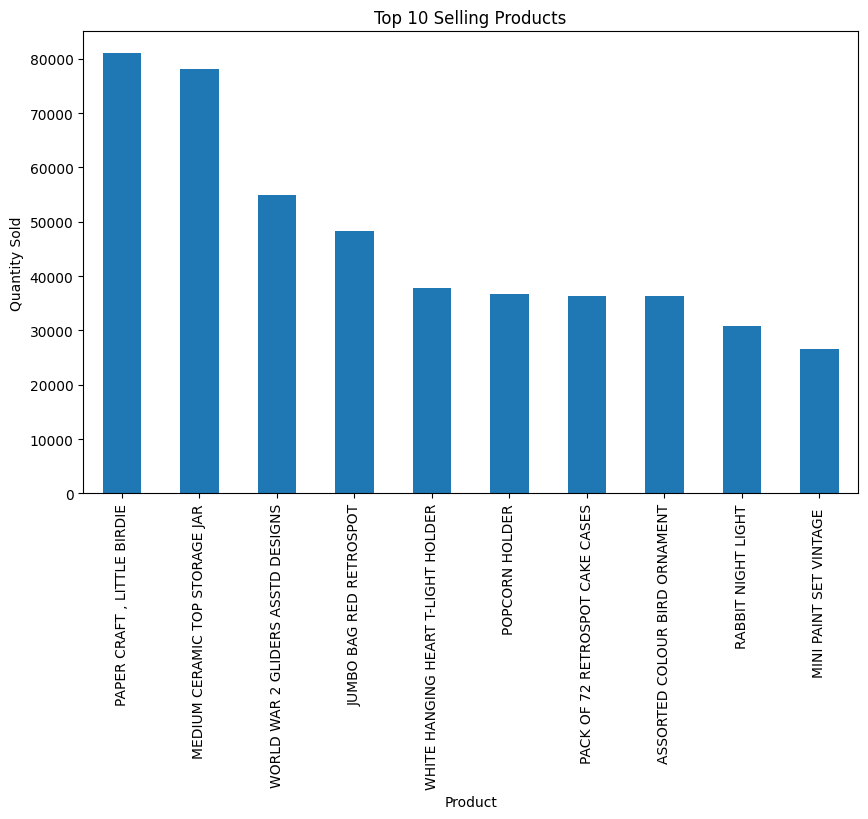

In [ ]:
plt.figure(figsize=(10,6))

top_products.plot(kind='bar')

plt.title('Top 10 Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')

plt.xticks(rotation=90)

plt.show()

In [ ]:
country_sales = df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10)

country_sales

,revenue
country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


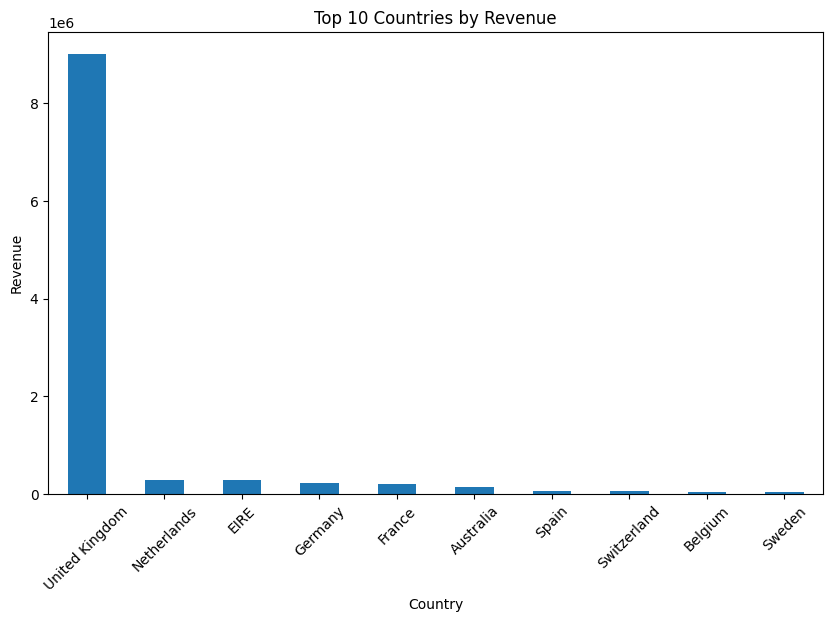

In [ ]:
plt.figure(figsize=(10,6))

country_sales.plot(kind='bar')

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')

plt.xticks(rotation=45)

plt.show()

In [ ]:
df['month'] = df['invoicedate'].dt.to_period('M')

monthly_sales = df.groupby('month')['revenue'].sum()

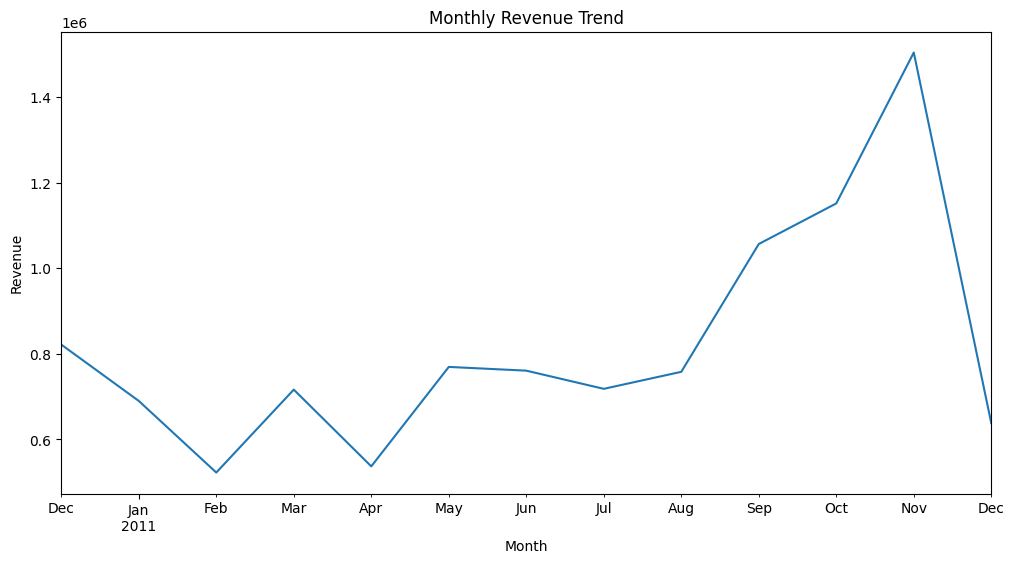

In [ ]:
plt.figure(figsize=(12,6))

monthly_sales.plot()

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

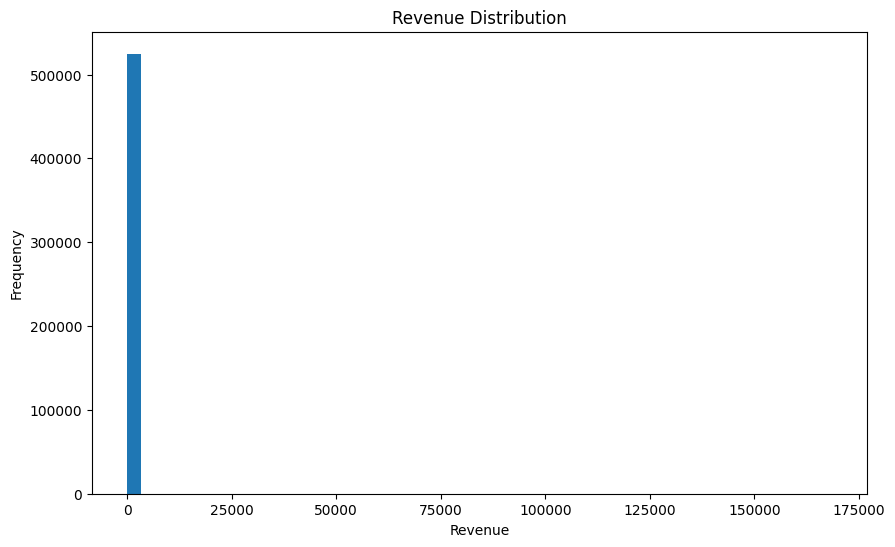

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(df['revenue'], bins=50)

plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

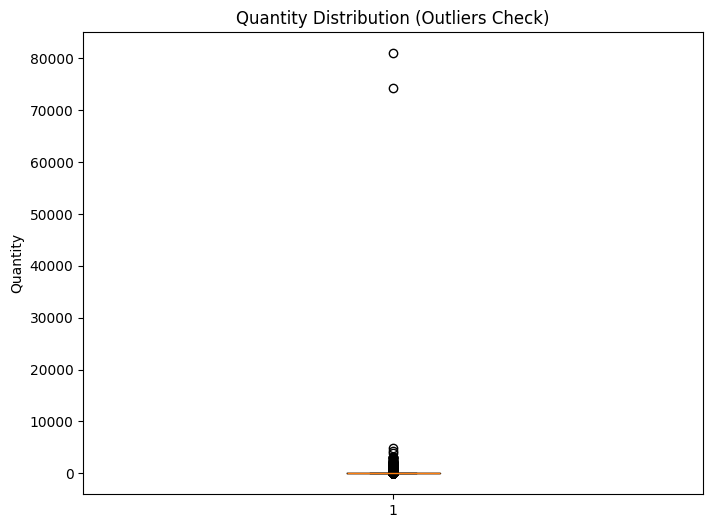

In [ ]:
plt.figure(figsize=(8,6))
plt.boxplot(df['quantity'])

plt.title('Quantity Distribution (Outliers Check)')
plt.ylabel('Quantity')
plt.show()

In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,541909.000000,541909,541909.000000,406829.000000,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,17.987795
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,-168469.600000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,3.400000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,9.750000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,17.400000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000
std,218.081158,NaN,96.759853,1713.600303,378.810824




## Cleaning Challenges Encountered

Several data quality issues were identified during the data cleaning process. Missing values were observed in the `Description` and `CustomerID` columns, requiring careful handling to preserve the integrity of the analysis. Additionally, 5,268 duplicate records were detected and removed to eliminate redundancy and prevent double-counting of transactions. Cancelled transactions, identified by invoice numbers beginning with the letter "C", were excluded from the dataset to ensure that only valid sales activities were analyzed. Data types, particularly date fields, were standardized to facilitate time-based analyses and improve consistency across the dataset.

## Key EDA Findings

Exploratory Data Analysis revealed important business patterns within the dataset. The analysis showed that a relatively small number of products accounted for a large proportion of total sales volume. Revenue generation varied significantly across countries, with the United Kingdom emerging as the leading market. Monthly sales trends indicated fluctuations in customer demand, suggesting possible seasonal purchasing behavior. Furthermore, customer purchasing patterns showed that most transactions involved modest order quantities, while a smaller number of transactions contributed disproportionately to total revenue.

## Top Insights

1. The United Kingdom represents the organization's strongest market in terms of revenue generation and customer activity.
2. Sales performance is highly influenced by a limited number of top-performing products, highlighting the importance of effective inventory management and product prioritization.
3. The presence of seasonal trends in sales suggests opportunities for targeted promotional campaigns during peak demand periods.
4. Most customers make relatively small purchases, indicating a predominance of low-volume transactions within the business model.
5. Thorough data cleaning significantly improved the quality and reliability of the analysis, emphasizing the critical role of data preparation in the analytics process.
